# 06 - PCA(0.90) + KNN  (the cautionary tale)

This notebook trains the original PCA + KNN pipeline that
scored only about 0.51 accuracy. The reason is going to
show up in the cell that prints pca.n_components_: PCA
keeps exactly 1 component for 90% variance, because the
nutrition columns with their big outliers hijack the
projection. After that KNN is doing similarity search on
a 1-D projection of the data. See research.md section 4
Lesson #5.

The fix for this is in 07_PCA_KNN_Improved.ipynb.

## 1 - Setup

Here we set matplotlib to inline mode, add the project root
to sys.path so we can import from src/, and bring in the
shared helpers together with the project-wide RANDOM_STATE = 42
(bound once in src/_constants.py, re-exported via src).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# notebooks/ sits one level under the project root, so we add
# the project root to make `from src import ...` work.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_test_index,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (bound once in src/_constants.py)")

RANDOM_STATE = 42 (bound once in src/_constants.py)


## 2 - Load the preprocessed feature matrices

load_preprocessed() gives us back the two matrices that we
made in Phase 1: the Baseline (just nutrition + tags) and
the Advanced (the Baseline plus 9 engineered culinary
features). They share the same train/test split so the A/B
comparison is fair.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 - Configure the pipeline

PCA(n_components=0.90) keeps the smallest set of principal
components that together cover 90% of the input variance.
KNN(n_neighbors=5) then works in that reduced space. Both
stages share the same random_state. KNN by itself is
deterministic (no random_state for it).

In [3]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

MODEL_SLUG    = "pca_knn"
MODEL_NAME    = "PCA(0.90) + KNN"
DISPLAY_NAME  = "PCA(0.90) + KNN"

PCA_VARIANCE = 0.90
KNN_NEIGHBORS = 5
MODEL_CONFIG = {
    "pca": {"n_components": PCA_VARIANCE, "random_state": RANDOM_STATE},
    "knn": {"n_neighbors": KNN_NEIGHBORS, "n_jobs": -1},
}

def _build_model():
    return Pipeline(steps=[
        ("pca", PCA(**MODEL_CONFIG["pca"])),
        ("knn", KNeighborsClassifier(**MODEL_CONFIG["knn"])),
    ])
MODEL_CONFIG

{'pca': {'n_components': 0.9, 'random_state': 42},
 'knn': {'n_neighbors': 5, 'n_jobs': -1}}

## 4 - Train and capture pca.n_components_

Here we pull out the real number of components that PCA
actually kept. On this dataset it's exactly 1 - the
diagnostic is in the next cell.

In [4]:
per_ds_results = {}
pca_components_per_dataset = {}

for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    pca_stage = result["model"].named_steps["pca"]
    n_components = int(pca_stage.n_components_)
    pca_components_per_dataset[ds_name] = n_components

    print_dataset_block(ds_name, X_train.shape, result)
    print(f"     PCA components retained for 90% variance : {n_components}")
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
save_test_index(MODEL_SLUG, y_test)
display(pd.Series(pca_components_per_dataset, name="components retained at 90% variance").to_frame())


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5147
     Test F1-Score : 0.5565
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          766       932   FP rate = 0.5489
        True:Hit           837      1110   FN rate = 0.4299
     PCA components retained for 90% variance : 1

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5092
     Test F1-Score : 0.5508
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          759       939   FP rate = 0.5530
        True:Hit           850      1097   FN rate = 0.4366
     PCA components retained for 90% variance : 1

  >> Δ (Advanced − Baseline):  Acc -0.0055  |  F1 -0.0057


,components retained at 90% variance
Baseline,1
Advanced,1


## 5 - Confusion matrix (Advanced fit)

An annotated heatmap of the confusion matrix from the
Advanced fit. We render it inline and also save it to
results/<slug>/confusion_matrix.png.

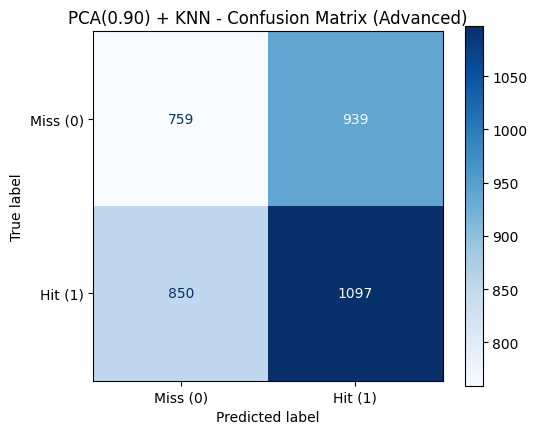

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} - Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 - ROC curve + AUC (Advanced fit)

We use predict_proba (or decision_function if the model
doesn't have probabilities). The AUC tells us how well the
model ranks the positives over the negatives, regardless of
the threshold we pick. Phase 4's threshold sweep is built
on top of this.

Test ROC AUC (Advanced): 0.5140


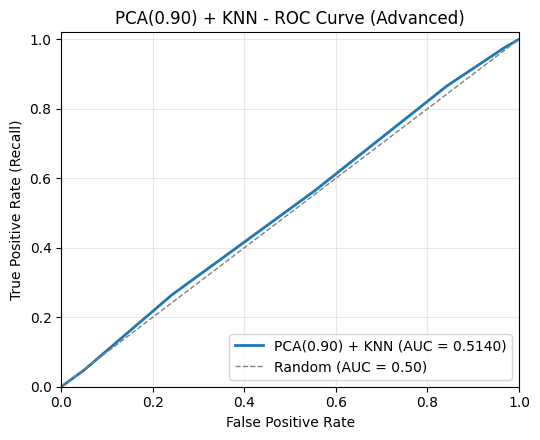

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} - ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 - Persist the canonical metrics JSON

One JSON per model, written into
results/<slug>/metrics.json. The schema is defined in
src.train_utils.build_metrics_payload, and the master
comparison notebook reads from those files.

In [7]:
extras = {
    "pca_components_retained": pca_components_per_dataset,
    "pca_variance_threshold":  PCA_VARIANCE,
    "knn_n_neighbors":         KNN_NEIGHBORS,
    "roc_auc_advanced":        auc,
}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/pca_knn/metrics.json


## 9 - Summary

    **Model:** PCA(0.90) + KNN  (the cautionary tale)

    - **Test Accuracy / F1:** about 0.5092 / 0.5508 - below the
  0.534 majority-class rate.
- **PCA kept just 1 component** - the diagnostic that pushed
  us to write 07_PCA_KNN_Improved.ipynb.
- **The lesson:** we should grab structural diagnostics
  before reasoning only from theory (research.md section 4
  Lesson #5).

    To see this model side by side with the other six, run the
    master comparison notebook (`08_Master_Comparison.ipynb`).